# Understanding Middleware in LangChain and DeepAgents

## Lesson Goal

By the end of this lesson, students should understand:

- What agents are
- What the agent loop is
- What middleware is in LangChain
- Why middleware exists architecturally
- How middleware interacts with the agent loop
- How to use built-in middleware
- How to create custom middleware
- How DeepAgents use middleware to extend runtime behavior


## 0. Setup

This notebook is written for the modern LangChain agent APIs.

Install dependencies:

In [18]:
# pip install -U langchain langgraph python-dotenv

If you plan on running this code, you will need an AI API key.

Initialize a model from a chat model provider of your choice. See [this page](https://docs.langchain.com/oss/python/langchain/models#google-gemini) for instructions.

In this demo, I will be using Gemini:

In [19]:
# pip install -U "langchain[google-genai]"

In [20]:
# Optional: load GOOGLE_API_KEY from a .env file
try:
    from dotenv import load_dotenv
    load_dotenv()
except ImportError:
    pass

In [ ]:
# Alternatively, paste your API key here
import os
os.environ["GOOGLE_API_KEY"] = "[REPLACE_WITH_YOUR_API_KEY]"

In [28]:
# Create Agent
from langchain.agents import create_agent
from langchain.tools import tool
from langchain.chat_models import init_chat_model

model = init_chat_model("google_genai:gemini-2.5-flash-lite")

## 1. Motivation: Why Agents Need Control Systems

### Scenario

Throughout this lesson, we will build a small AI Finance Operations Assistant.

This assistant can:

- reimburse employees
- send payments
- access invoices
- send finance emails

At first glance, building the assistant seems straightforward. But once agents become capable of taking actions, we quickly run into operational questions:

- How do we log actions for auditing?
- How do we require approval for risky actions?
- How do we prevent unsafe tool usage?

These concerns are not part of the agent's reasoning logic. Rather, they are runtime concerns. This is where middleware becomes useful.


## 2. What is an Agent?

An agent is an LLM system that can:

- reason about a task
- decide which tools to use
- observe tool results
- continue iterating until the task is complete

Unlike a simple chatbot, an agent can take actions.


## 3. What is the Agent Loop?

The core execution cycle of an agent is often called the agent loop. This is the internal cycle where the model reasons, calls tools, observes results, and decides what to do next.

### Agent Loop Diagram

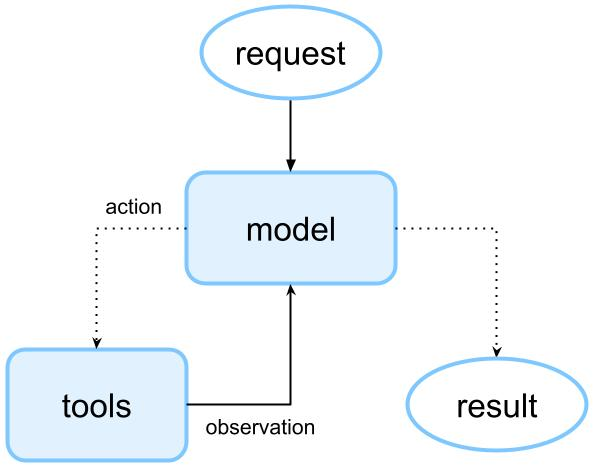

Middleware wraps or intercepts parts of this loop.

## 4. Define Finance Tools

Let's consider the financial scenario from earlier. We can define a small set of reasonable tools that we'll use throughout the notebook. In a real-world application, each tool would have distinct functionality.

In [29]:
@tool
def reimburse_employee(employee_name: str, amount_usd: float, reason: str) -> str:
    """Reimburse an employee for an approved business expense."""
    return f"Reimbursed {employee_name} ${amount_usd:,.2f} for: {reason}"


@tool
def lookup_invoice(vendor_name: str) -> str:
    """Look up invoice status for a vendor."""
    invoices = {
        "Acme Catering": "Invoice #A-1029 is pending approval for $850.",
        "Northstar Events": "Invoice #N-7781 is paid.",
        "Bluebird Travel": "Invoice #B-4420 is missing a receipt.",
    }
    return invoices.get(vendor_name, f"No invoice found for {vendor_name}.")


@tool
def send_payment(vendor_name: str, amount_usd: float, memo: str) -> str:
    """Send a payment to a vendor. This is a high-risk action."""
    return f"Sent ${amount_usd:,.2f} to {vendor_name}. Memo: {memo}"


@tool
def draft_finance_email(recipient: str, subject: str, body: str) -> str:
    """Draft an email to the finance team or a vendor."""
    return f"Drafted email to {recipient} with subject: {subject}"

We'll store these tools in a list for easy access:

In [30]:
tools = [
    reimburse_employee,
    lookup_invoice,
    send_payment,
    draft_finance_email,
]

## 5. Baseline Agent: No Middleware

Let's try creating our finance assistant without middleware. This helps us see the core agent loop before adding runtime controls.

Here, we create the agent with a simple system prompt and ask the agent to look up an invoice.

In [31]:
baseline_agent = create_agent(
    model=model,
    tools=tools,
    system_prompt=(
        "You are a finance operations assistant. "
        "Help with reimbursements, invoices, and vendor payments. "
        "Be concise and explain what action you took."
    ),
)

In [32]:
result = baseline_agent.invoke({
    "messages": [
        {"role": "user", "content": "Look up the invoice for Acme Catering."}
    ]
})

result["messages"][-1].content

'I looked up the invoice for Acme Catering. It is invoice #A-1029 for $850 and it is pending approval.'

### What problems still exist?

The baseline agent can use tools, but there are no controls around execution. For a finance assistant, that is risky.

For example:

```text
User: Send a $25,000 payment to a vendor.
```

Should the agent be allowed to do that automatically? Likely, no. That is where middleware comes in.

## 6. What is Middleware?

Middleware is a reusable layer that intercepts agent execution so you can

1. observe execution
2. modify execution
3. interrupt execution

without changing the core agent logic.

In LangChain, middleware wraps the agent loop and is commonly used for:

- logging
- approvals
- retries
- summarization
- safety guardrails
- model routing
- observability

### Middleware Execution Lifecycle

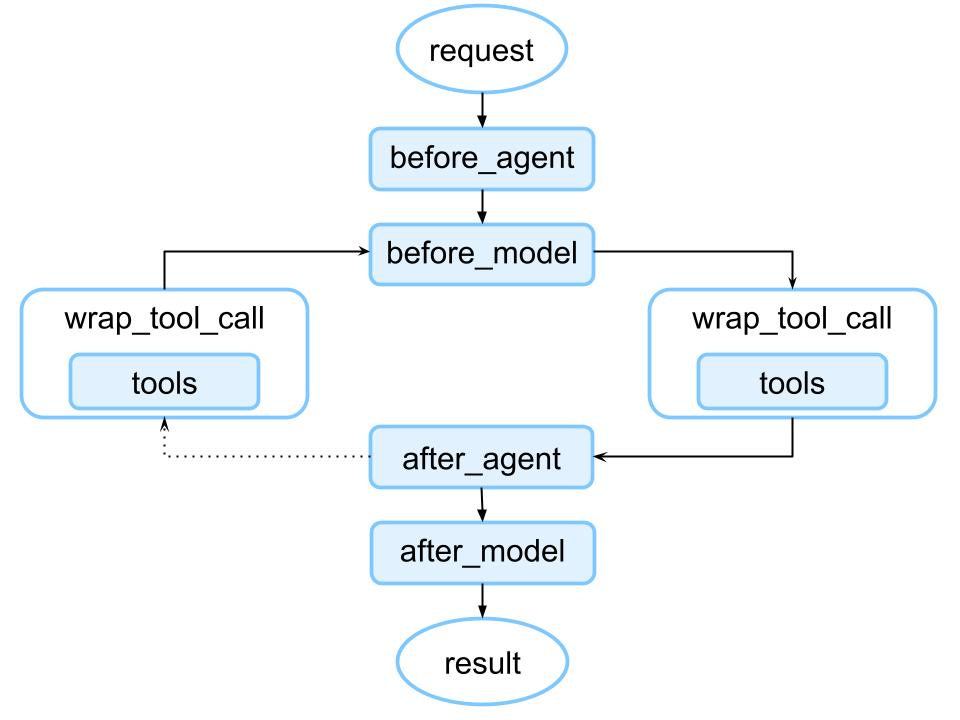

Middleware can run:

- before the model is called
- around the model call
- around a tool call
- after the model responds
- after the agent finishes

## 7. Prebuilt Middleware

Langchain offers both prebuilt and custom middleware. Prebuilt middleware is production-ready and easily configurable for your specific needs.

### 7a. Prebuilt Middleware Example: Human-in-the-Loop Approval

As we build our finance assistant, it's important to keep in mind that a given function may require approval before it is processed. In other words, some actions should pause before execution.

For our finance assistant:

- looking up an invoice is safe
- reimbursing $45 may be safe
- sending vendor payments is risky

LangChain's `HumanInTheLoopMiddleware` can interrupt before selected tools execute. See the API reference [here](https://reference.langchain.com/python/langchain/agents/middleware/human_in_the_loop/HumanInTheLoopMiddleware).

> Note: Human-in-the-loop middleware requires a checkpointer so the agent can pause and resume.

In [33]:
from langchain.agents.middleware import HumanInTheLoopMiddleware
from langgraph.checkpoint.memory import InMemorySaver

approval_agent = create_agent(
    model=model,
    tools=tools,
    checkpointer=InMemorySaver(),
    system_prompt="You are a finance assistant. Payments require approval.",
    middleware=[
        HumanInTheLoopMiddleware(
            interrupt_on={
                # Here we can map the tool name to the allowed decisions
                # The DecisionTypes include 'approve', 'edit', 'reject', and 'respond'
                "send_payment": {
                    "allowed_decisions": ["approve", "edit", "reject"],
                },
                # These tools can run without approval.
                "lookup_invoice": False,
                "reimburse_employee": False,
                "draft_finance_email": False,
            }
        )
    ],
)

In [34]:
# This request should pause before send_payment executes.

config = {"configurable": {"thread_id": "finance-approval-demo"}}
approval_result = approval_agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Send a $25,000 payment to Acme Catering for invoice A-1029.",
            }
        ]
    },
    config=config,
)

approval_result

{'messages': [HumanMessage(content='Send a $25,000 payment to Acme Catering for invoice A-1029.', additional_kwargs={}, response_metadata={}, id='97cfc397-35ca-4480-8317-55b37a7adb1f'),
  AIMessage(content='I can help with that. Can you confirm that invoice A-1029 has been approved?', additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019e1f01-838b-77e3-8457-9b90b96ca9f7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 294, 'output_tokens': 21, 'total_tokens': 315, 'input_token_details': {'cache_read': 0}})]}

From this result, we can see that the middleware interrupted execution before the payment tool could run.

The core agent did not change. The payment tool did not change. The middleware inserted an approval gate around risky execution. This is an example of an interruption.

### 7b. Prebuilt Middleware Example: PII Protection

LangChain provides `PIIMiddleware` as a prebuilt option to detect and handle personally identifiable information. See the API reference [here](https://reference.langchain.com/python/langchain/agents/middleware/pii/PIIMiddleware?_gl=1*kdcndd*_gcl_au*MTcxMzIyOTgyOC4xNzc3MzE0MjI0*_ga*MTM2MzM1NzYzMy4xNzc3MzE0MjI0*_ga_47WX3HKKY2*czE3Nzg2MjQ4MjkkbzExJGcxJHQxNzc4NjI1NTg1JGo2MCRsMCRoMA..).

Finance workflows often include sensitive information. In this example, our finance assistant will redact emails and mask credit card numbers before they reach the model.

In [35]:
from langchain.agents.middleware import PIIMiddleware

pii_agent = create_agent(
    model=model,
    tools=[lookup_invoice, draft_finance_email],
    system_prompt="You are a finance assistant. Do not expose sensitive user data.",
    middleware=[
        # Here we can specify the type of PIIs and configure the strategy for each
        PIIMiddleware("email", strategy="redact", apply_to_input=True),
        PIIMiddleware("credit_card", strategy="mask", apply_to_input=True),
    ],
)

In [36]:
pii_result = pii_agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": (
                "Please draft a note to finance@company.com. "
                "Also, my card number is 4111 1111 1111 1111."
            ),
        }
    ]
})

pii_result["messages"][-1].content

'I can help draft a note for you. What is the subject and body of the email? Please note, I will not be able to include your card number.'

Rather than rewriting the finance agent, we added a reusable privacy control around execution. This is an example of a modification.

## 8. Custom Middleware

Custom middleware allows developers to add their own runtime behavior around the agent loop, such as logging, approvals, model routing, or tool restrictions. LangChain supports two primary middleware patterns: node-style hooks and wrap-style hooks.

Node-style hooks run at specific execution points (such as before or after a model call) and are useful for lightweight observation or state updates. Wrap-style hooks surround execution itself, giving middleware full control to observe, modify, interrupt, or replace model and tool behavior before passing execution to the next layer.

### 8a. Custom Middleware Example: Monitor Tool Calls

Now let's write custom middleware. `wrap_tool_call` lets middleware run around each tool call.

This is useful when you need runtime control over tool execution, such as:

- logging tool usage
- enforcing permissions
- handling errors
- adding approvals
- blocking unsafe actions before the tool runs

See the API reference [here](https://reference.langchain.com/python/langchain/agents/middleware/types/AgentMiddleware/wrap_tool_call).

In this example, our finance assistant will create an audit trail by logging the tool requested, its arguments, and completion status.

In [37]:
from collections.abc import Callable
from langchain.agents.middleware import wrap_tool_call
from langchain.messages import ToolMessage
from langchain.tools.tool_node import ToolCallRequest
from langgraph.types import Command

@wrap_tool_call
def audit_tool_call(
    # ToolCallRequest objects contain the execution context for a tool invocation,
    # including the tool name, args, and runtime info needed by middleware during a tool call
    request: ToolCallRequest,
    handler: Callable[[ToolCallRequest], ToolMessage | Command],
) -> ToolMessage | Command:
    tool_name = request.tool_call["name"]
    tool_args = request.tool_call["args"]

    print(f"[audit] Tool requested: {tool_name}")
    print(f"[audit] Tool args: {tool_args}")

    try:
        result = handler(request)
        print(f"[audit] Tool completed: {tool_name}")
        return result
    except Exception as error:
        print(f"[audit] Tool failed: {tool_name} | {error}")
        raise

In [38]:
audit_agent = create_agent(
    model=model,
    tools=tools,
    system_prompt="You are a finance assistant.",
    middleware=[audit_tool_call],
)

audit_result = audit_agent.invoke({
    "messages": [
        {"role": "user", "content": "Look up the invoice for Acme Catering."}
    ]
})

audit_result["messages"][-1].content

[audit] Tool requested: lookup_invoice
[audit] Tool args: {'vendor_name': 'Acme Catering'}
[audit] Tool completed: lookup_invoice


'The invoice #A-1029 for Acme Catering is pending approval for $850.'

Here we see that the middleware wraps the tool execution step of the agent loop. The tool still does the work, the middleware just governs how the tool execution is monitored. This is an example of an observation.

The whole process follows this flow:

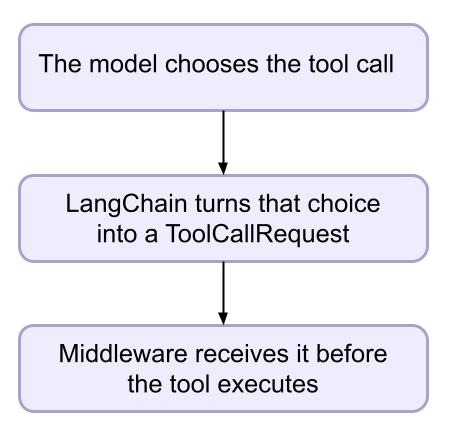

### 8b. Custom Middleware: Block High-Risk Tool Calls

Now let's make the middleware more active by allowing it to interrupt execution.

In this example, the finance assistant will block `send_payment` calls over $1,000.

> Note: This is not a replacement for real payment authorization, but it demonstrates the pattern.

In [39]:
@wrap_tool_call
def block_large_payments(
    request: ToolCallRequest,
    handler: Callable[[ToolCallRequest], ToolMessage | Command],
) -> ToolMessage | Command:
    tool_name = request.tool_call["name"]
    tool_args = request.tool_call["args"]

    if tool_name == "send_payment":
        amount = float(tool_args.get("amount_usd", 0))

        if amount > 1000:
            return ToolMessage(
                content=(
                    f"Payment blocked by middleware. "
                    f"Payments over $1,000 require human approval. Requested: ${amount:,.2f}."
                ),
                tool_call_id=request.tool_call["id"],
            )

    return handler(request)

In [40]:
guarded_agent = create_agent(
    model=model,
    tools=tools,
    system_prompt=(
        "You are a finance assistant. "
        "If a tool returns a policy error, explain it clearly to the user."
    ),
    # Note that we can use both audit_tool_call and block_large_payments as the middleware
    middleware=[audit_tool_call, block_large_payments],
)

In [41]:
safe_payment = guarded_agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "Send a $250 payment to Acme Catering for snacks.",
        }
    ]
})

safe_payment["messages"][-1].content

[audit] Tool requested: send_payment
[audit] Tool args: {'vendor_name': 'Acme Catering', 'amount_usd': 250, 'memo': 'snacks'}
[audit] Tool completed: send_payment


'The payment of $250.00 to Acme Catering for snacks has been sent.'

In the above example payment, the \$250 amount is below the blocking limit \$1000, so the tool runs as expected.

In [42]:
blocked_payment = guarded_agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": "Send a $25,000 payment to Acme Catering for invoice A-1029.",
        }
    ]
})

blocked_payment["messages"][-1].content

[audit] Tool requested: send_payment
[audit] Tool args: {'vendor_name': 'Acme Catering', 'amount_usd': 25000, 'memo': 'Invoice A-1029'}
[audit] Tool completed: send_payment


'The payment of $25,000 to Acme Catering could not be processed because it requires human approval. Payments over $1,000 are automatically blocked by a security measure and need to be approved by a finance professional.'

In this example, the middleware returns a ToolMessage directly instead of calling the actual tool. This effectively short-circuits execution by simulating a tool response, allowing the agent loop to continue normally even though the real tool never ran.

This is an example of middleware interrupting and replacing execution.

Middleware can call the handler normally:

```python
return handler(request)
```

Or it can short-circuit execution:

```python
return ToolMessage(...)
```

That means middleware can decide whether the next layer of execution should run.

## 9. DeepAgents Connection

DeepAgents are higher-level agent runtimes built on LangGraph.

The agents in this notebook are standard LangChain agents enhanced with middleware. DeepAgents build on these same middleware and LangGraph concepts, but provide a more advanced runtime designed for long-running workflows, planning, memory, subagents, and durable execution.

DeepAgents use middleware extensively.

## 10. Additional Notes

### Custom Middleware

LangChain supports both decorator-based and class-based middleware. Decorator-based middleware is lightweight and ideal for simple, single-hook behaviors like logging or request modification, while class-based middleware is better for more complex middleware that combines multiple hooks, shared configuration, or reusable state across executions.

For this lesson, we used primarily decorator-based middleware because it keeps the middleware behavior easy to visualize and understand.

#### Extending the Finance Example

In this notebook, we use finance approvals. However, the same middleware pattern could also apply to:

- medical systems
- customer support
- DevOps agents
- autonomous coding agents